In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/annotations.xml
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/receipts.csv
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/11.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/4.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/9.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/14.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/1.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/2.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/10.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/18.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/12.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/7.png
/kaggle/input/datasets/trainingdatapro/ocr

# PaddleOCR 

現時点でのSOTAで、普通のOCRモデルやVLMも用意されている。また、それぞれ、ローカル環境、デバイス上で動かすのに最適な軽量モデルも用意されている。

以下が、githubとhugging faceのページである。

https://github.com/PaddlePaddle/PaddleOCR

https://huggingface.co/PaddlePaddle　

# pip

In [3]:
!python -m pip install paddlepaddle==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/ -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.9/192.9 MB 5.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.1 MB/s eta 0:00:00


In [4]:
!python -m pip install paddleocr -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 25.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 80.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.7/415.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [5]:
!pip install llama-cpp-python \
  --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cpu -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 MB 5.5 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00


In [6]:
!git clone https://github.com/ggml-org/llama.cpp.git -q

In [7]:
!pip install -q huggingface_hub

In [8]:
!pip install -U paddlex[ocr] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.7/385.7 kB 15.2 MB/s eta 0:00:00


# ライブラリ

In [9]:
import paddle
import paddleocr
import paddlex
from paddleocr import TextDetection
from paddleocr import TextRecognition
from paddleocr import PaddleOCRVL

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import json
from IPython.display import display, JSON, Markdown

import subprocess
import time
import requests

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


# モデル準備

**OCR model**

In [10]:
detection = TextDetection(model_name="PP-OCRv5_mobile_det")
recognition = TextRecognition(model_name="PP-OCRv5_mobile_rec")

Using official model (PP-OCRv5_mobile_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Using official model (PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

**VLM**

In [11]:
print(detection)
print(recognition)

# データセット準備

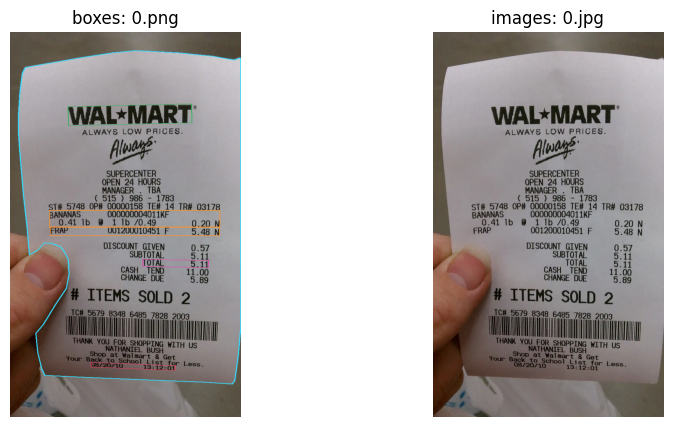

In [12]:
# =========================
# パス設定
# =========================
base_path = Path("/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection")

boxes_path = base_path / "boxes"
images_path = base_path / "images"

# =========================
# 画像取得関数
# =========================
def get_first_image(folder_path):
    image_files = sorted(
        list(folder_path.glob("*.png")) +
        list(folder_path.glob("*.jpg")) +
        list(folder_path.glob("*.jpeg"))
    )
    if len(image_files) == 0:
        return None
    return image_files[0]

# =========================
# 画像取得
# =========================
boxes_img_path = get_first_image(boxes_path)
images_img_path = get_first_image(images_path)

# =========================
# 表示
# =========================
plt.figure(figsize=(10, 5))

# boxes
if boxes_img_path:
    plt.subplot(1, 2, 1)
    img = Image.open(boxes_img_path)
    plt.imshow(img)
    plt.title(f"boxes: {boxes_img_path.name}")
    plt.axis("off")

# images
if images_img_path:
    plt.subplot(1, 2, 2)
    img = Image.open(images_img_path)
    plt.imshow(img)
    plt.title(f"images: {images_img_path.name}")
    plt.axis("off")

plt.show()

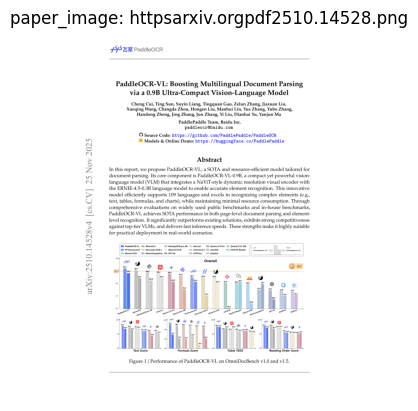

In [13]:
# =========================
# パス設定
# =========================
image_dir = Path("/kaggle/input/datasets/itsuki0911/paper-image")

# =========================
# 画像ファイル取得（最初の1枚）
# =========================
image_files = sorted(
    list(image_dir.glob("*.png")) +
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.jpeg"))
)

# =========================
# paper_imageとして読み込み
# =========================
paper_image_path = image_files[0]
paper_image = Image.open(paper_image_path)

# =========================
# 表示
# =========================
plt.imshow(paper_image)
plt.title(f"paper_image: {paper_image_path.name}")
plt.axis("off")
plt.show()

# モデル性能テスト(簡易版)

{'res': {'input_path': '/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/images/0.jpg', 'page_index': None, 'dt_polys': array([[[351, 878],
        ...,
        [349, 896]],

       ...,

       [[151, 191],
        ...,
        [151, 251]]], dtype=int16), 'dt_scores': [0.7477945674961743, 0.7703490275966486, 0.6816398614768754, 0.7940038263506364, 0.669712591327141, 0.7987527347783058, 0.8286386437024466, 0.8407125445375669, 0.8293906040252189, 0.8253880324044095, 0.8787204097116075, 0.7579689493504598, 0.834551092543333, 0.7587927965031759, 0.8409374819807862, 0.6129471760237489, 0.8483052808147128, 0.6670808511218991, 0.7797004518148071, 0.9157181852540669, 0.8542948596232706, 0.867319180020779, 0.8770024783915968, 0.8555843228569492, 0.7178931521667238, 0.8638660269055741, 0.8210849121955708, 0.8487139839557392, 0.8451390480912042, 0.6531330401886261, 0.8503585200837768, 0.8040895772333498, 0.9036408544938642, 0.8963056897156838, 0.7975462134487853, 0.789210887653

===== Result 0 =====

保存した画像:
/kaggle/working/paddle_results/det_result_0.jpg

保存したJSON:
/kaggle/working/paddle_results/det_result_0.json


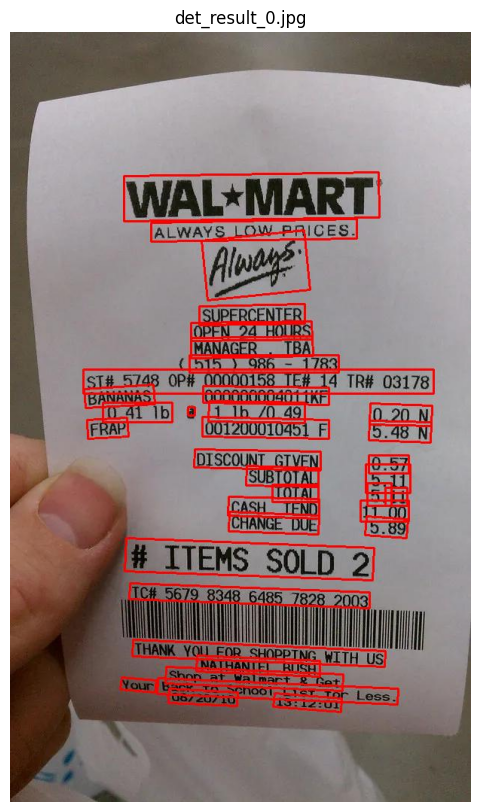

<IPython.core.display.JSON object>

In [14]:
# =========================
# 保存先ディレクトリ
# =========================
save_dir = Path("/kaggle/working/paddle_results")
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 推論
# ※ bacth_size -> batch_size に修正
# ※ input は文字列パスにする
# =========================
output = detection.predict(input=str(images_img_path), batch_size=1)

# =========================
# 結果保存
# =========================
saved_image_paths = []
saved_json_paths = []

for i, res in enumerate(output):
    print(f"===== Result {i} =====")
    res.print()

    image_save_path = save_dir / f"det_result_{i}.jpg"
    json_save_path = save_dir / f"det_result_{i}.json"

    res.save_to_img(save_path=str(image_save_path))
    res.save_to_json(save_path=str(json_save_path))

    saved_image_paths.append(image_save_path)
    saved_json_paths.append(json_save_path)

# =========================
# 保存先確認
# =========================
print("\n保存した画像:")
for p in saved_image_paths:
    print(p)

print("\n保存したJSON:")
for p in saved_json_paths:
    print(p)

# =========================
# 保存画像を表示
# =========================
if len(saved_image_paths) > 0:
    result_image = Image.open(saved_image_paths[0])

    plt.figure(figsize=(10, 10))
    plt.imshow(result_image)
    plt.title(saved_image_paths[0].name)
    plt.axis("off")
    plt.show()

# =========================
# jsonを表示
# =========================
import json
from pathlib import Path
from IPython.display import display, JSON

json_path = Path("/kaggle/working/paddle_results/det_result_0.json")

with open(json_path, "r") as f:
    data = json.load(f)

display(JSON(data))

In [15]:
from pathlib import Path
import json
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# =====================================
# 0. 元画像パス
# detection をかけた元画像
# =====================================
input_image_path = Path(images_img_path)
original_image = Image.open(input_image_path).convert("RGB")

# =====================================
# 1. 既存の detection 結果JSON
# =====================================
det_json_path = Path("/kaggle/working/paddle_results/det_result_0.json")

with open(det_json_path, "r", encoding="utf-8") as f:
    det_data = json.load(f)

print("===== detection JSON 読み込み完了 =====")
print(type(det_data))

# =====================================
# 2. 保存先
# =====================================
base_save_dir = Path("/kaggle/working/ocr_from_det_json")
crop_dir = base_save_dir / "crops"
rec_json_dir = base_save_dir / "recognition_json"
crop_dir.mkdir(parents=True, exist_ok=True)
rec_json_dir.mkdir(parents=True, exist_ok=True)

# =====================================
# 3. detection JSON から polygon を取り出す
# =====================================
def extract_polygons(det_data):
    if isinstance(det_data, dict):
        for key in ["dt_polys", "polys", "boxes"]:
            if key in det_data:
                return det_data[key]

    if isinstance(det_data, list) and len(det_data) > 0:
        if isinstance(det_data[0], dict):
            for key in ["dt_polys", "polys", "boxes"]:
                if key in det_data[0]:
                    return det_data[0][key]

    raise ValueError("Detection JSONから文字領域座標を取得できませんでした。JSONの中身を確認してください。")

polygons = extract_polygons(det_data)
print(f"検出領域数: {len(polygons)}")

# =====================================
# 4. polygon から外接矩形で crop
# =====================================
def crop_from_polygon(image, poly):
    xs = [p[0] for p in poly]
    ys = [p[1] for p in poly]

    left = max(0, int(min(xs)))
    top = max(0, int(min(ys)))
    right = min(image.width, int(max(xs)))
    bottom = min(image.height, int(max(ys)))

    if right <= left or bottom <= top:
        return None

    return image.crop((left, top, right, bottom))

# =====================================
# 5. cropして recognition
# =====================================
all_results = []

for idx, poly in enumerate(polygons):
    crop_img = crop_from_polygon(original_image, poly)

    if crop_img is None:
        print(f"[skip] crop失敗: {idx}")
        continue

    crop_path = crop_dir / f"crop_{idx}.png"
    crop_img.save(crop_path)

    rec_output = recognition.predict(input=str(crop_path), batch_size=1)

    rec_text = ""
    rec_score = 0.0
    rec_json_path = rec_json_dir / f"rec_{idx}.json"

    for res in rec_output:
        res.print()
        res.save_to_json(save_path=str(rec_json_path))

        with open(rec_json_path, "r", encoding="utf-8") as f:
            rec_data = json.load(f)

        if isinstance(rec_data, dict):
            rec_text = rec_data.get("rec_text", "")
            rec_score = rec_data.get("rec_score", 0.0)

    all_results.append({
        "crop_index": idx,
        "polygon": poly,
        "crop_path": str(crop_path),
        "rec_text": rec_text,
        "rec_score": rec_score
    })

# =====================================
# 6. 全結果を保存
# =====================================
final_json_path = base_save_dir / "final_recognition_results.json"
with open(final_json_path, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print(f"\n保存完了: {final_json_path}")

# =====================================
# 7. 結果を表示
# =====================================
print("\n===== Recognition結果一覧 =====")
for item in all_results:
    print(
        f"[{item['crop_index']}] "
        f"text='{item['rec_text']}' "
        f"score={item['rec_score']}"
    )

===== detection JSON 読み込み完了 =====
<class 'dict'>
検出領域数: 37


{'res': {'input_path': '/kaggle/working/ocr_from_det_json/crops/crop_0.png', 'page_index': None, 'rec_text': '13:12:01', 'rec_score': 0.9696527719497681}}
{'res': {'input_path': '/kaggle/working/ocr_from_det_json/crops/crop_1.png', 'page_index': None, 'rec_text': '08/20/10', 'rec_score': 0.9899867177009583}}
{'res': {'input_path': '/kaggle/working/ocr_from_det_json/crops/crop_2.png', 'page_index': None, 'rec_text': 'Bakoschol Listfor Less.', 'rec_score': 0.5953447222709656}}
{'res': {'input_path': '/kaggle/working/ocr_from_det_json/crops/crop_3.png', 'page_index': None, 'rec_text': 'Your', 'rec_score': 0.9885075092315674}}
{'res': {'input_path': '/kaggle/working/ocr_from_det_json/crops/crop_4.png', 'page_index': None, 'rec_text': 'Shop at Walmart 8 Get', 'rec_score': 0.9345400929450989}}
{'res': {'input_path': '/kaggle/working/ocr_from_det_json/crops/crop_5.png', 'page_index': None, 'rec_text': 'NATHANIEL BUSH', 'rec_score': 0.9696628451347351}}
{'res': {'input_path': '/kaggle/working/


保存完了: /kaggle/working/ocr_from_det_json/final_recognition_results.json

===== Recognition結果一覧 =====
[0] text='13:12:01' score=0.9696527719497681
[1] text='08/20/10' score=0.9899867177009583
[2] text='Bakoschol Listfor Less.' score=0.5953447222709656
[3] text='Your' score=0.9885075092315674
[4] text='Shop at Walmart 8 Get' score=0.9345400929450989
[5] text='NATHANIEL BUSH' score=0.9696628451347351
[6] text='THANK YOU FOR SHOPPING WITH US' score=0.9569369554519653
[7] text='TC# 5679 8348 6485 7828 2003' score=0.9452284574508667
[8] text='# ITEMS SOLD 2' score=0.9246083498001099
[9] text='5.89' score=0.9905866384506226
[10] text='CHANGE DUE' score=0.9562371373176575
[11] text='11.00' score=0.9946830868721008
[12] text='CASH TEND' score=0.9672240018844604
[13] text='11' score=0.9968689680099487
[14] text='TOTAL' score=0.9964662790298462
[15] text='5.' score=0.9731330275535583
[16] text='SUBTOTAL' score=0.994437575340271
[17] text='5.11' score=0.991885244846344
[18] text='0.57' score=0.997

In [16]:
md = "## OCR結果一覧\n\n"

for item in all_results:
    md += f"### crop_{item['crop_index']}\n"
    md += f"- text: **{item['rec_text']}**\n"
    md += f"- score: {item['rec_score']}\n"
    md += f"- crop_path: `{item['crop_path']}`\n\n"

display(Markdown(md))

## OCR結果一覧

### crop_0
- text: **13:12:01**
- score: 0.9696527719497681
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_0.png`

### crop_1
- text: **08/20/10**
- score: 0.9899867177009583
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_1.png`

### crop_2
- text: **Bakoschol Listfor Less.**
- score: 0.5953447222709656
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_2.png`

### crop_3
- text: **Your**
- score: 0.9885075092315674
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_3.png`

### crop_4
- text: **Shop at Walmart 8 Get**
- score: 0.9345400929450989
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_4.png`

### crop_5
- text: **NATHANIEL BUSH**
- score: 0.9696628451347351
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_5.png`

### crop_6
- text: **THANK YOU FOR SHOPPING WITH US**
- score: 0.9569369554519653
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_6.png`

### crop_7
- text: **TC# 5679 8348 6485 7828 2003**
- score: 0.9452284574508667
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_7.png`

### crop_8
- text: **# ITEMS SOLD 2**
- score: 0.9246083498001099
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_8.png`

### crop_9
- text: **5.89**
- score: 0.9905866384506226
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_9.png`

### crop_10
- text: **CHANGE DUE**
- score: 0.9562371373176575
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_10.png`

### crop_11
- text: **11.00**
- score: 0.9946830868721008
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_11.png`

### crop_12
- text: **CASH TEND**
- score: 0.9672240018844604
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_12.png`

### crop_13
- text: **11**
- score: 0.9968689680099487
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_13.png`

### crop_14
- text: **TOTAL**
- score: 0.9964662790298462
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_14.png`

### crop_15
- text: **5.**
- score: 0.9731330275535583
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_15.png`

### crop_16
- text: **SUBTOTAL**
- score: 0.994437575340271
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_16.png`

### crop_17
- text: **5.11**
- score: 0.991885244846344
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_17.png`

### crop_18
- text: **0.57**
- score: 0.9977258443832397
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_18.png`

### crop_19
- text: **DISCOUNT GIVEN**
- score: 0.9593076705932617
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_19.png`

### crop_20
- text: **5.48N**
- score: 0.9956443905830383
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_20.png`

### crop_21
- text: **001200010451F**
- score: 0.9983552098274231
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_21.png`

### crop_22
- text: **FRAP**
- score: 0.9910477995872498
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_22.png`

### crop_23
- text: **0.20N**
- score: 0.9714856147766113
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_23.png`

### crop_24
- text: **F**
- score: 0.4766867756843567
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_24.png`

### crop_25
- text: **0.41 1b**
- score: 0.9254838824272156
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_25.png`

### crop_26
- text: **11b /0.49**
- score: 0.9244311451911926
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_26.png`

### crop_27
- text: **BANANAS**
- score: 0.9932894706726074
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_27.png`

### crop_28
- text: **000000004011KF**
- score: 0.9875683188438416
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_28.png`

### crop_29
- text: **ST#57480P#00000158 TE# 14 TR#03178**
- score: 0.9567735195159912
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_29.png`

### crop_30
- text: **515）986-1783**
- score: 0.9601032137870789
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_30.png`

### crop_31
- text: **MANAGERTBA**
- score: 0.9908933639526367
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_31.png`

### crop_32
- text: **OPEN 24 HOURS**
- score: 0.9074203968048096
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_32.png`

### crop_33
- text: **SUPERCENTER**
- score: 0.9958298206329346
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_33.png`

### crop_34
- text: **Always**
- score: 0.7618563771247864
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_34.png`

### crop_35
- text: **ALWAYS LOW PRICES.**
- score: 0.977575957775116
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_35.png`

### crop_36
- text: **WAL*MART**
- score: 0.9153543710708618
- crop_path: `/kaggle/working/ocr_from_det_json/crops/crop_36.png`



# PaddleOCR-VL

**サーバー準備**

llama.cppをコンパイルして、実行可能にする

In [27]:
!apt-get update # パッケージ情報の更新
!apt-get install -y build-essential cmake #開発に必要なツールをインストール

!cmake -S llama.cpp -B llama.cpp/build #ビルド設定：S->ソースディレクトリ、B->ビルド出力先
!cmake --build llama.cpp/build -j #実際にコンパイルする。　j->並列処理　　->実行ファイルが生成される

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]               
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease    
Get:9 https://cli.github.com/packages stable/main amd64 Packages [354 B]       
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,264 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates

In [30]:
from pathlib import Path

for p in Path("./llama.cpp").rglob("llama-server"):
    print(p)

llama.cpp/build/bin/llama-server


hugging faceからモデルを読み込む

In [19]:
from huggingface_hub import hf_hub_download
from pathlib import Path

save_dir = Path("/kaggle/working/paddleocr_vl_gguf")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = hf_hub_download(
    repo_id="PaddlePaddle/PaddleOCR-VL-1.5-GGUF",
    filename="PaddleOCR-VL-1.5.gguf",
    local_dir=str(save_dir),
    local_dir_use_symlinks=False
)

mmproj_path = hf_hub_download(
    repo_id="PaddlePaddle/PaddleOCR-VL-1.5-GGUF",
    filename="PaddleOCR-VL-1.5-mmproj.gguf",
    local_dir=str(save_dir),
    local_dir_use_symlinks=False
)

print("model_path =", model_path)
print("mmproj_path =", mmproj_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


PaddleOCR-VL-1.5.gguf:   0%|          | 0.00/936M [00:00<?, ?B/s]

PaddleOCR-VL-1.5-mmproj.gguf:   0%|          | 0.00/882M [00:00<?, ?B/s]

model_path = /kaggle/working/paddleocr_vl_gguf/PaddleOCR-VL-1.5.gguf
mmproj_path = /kaggle/working/paddleocr_vl_gguf/PaddleOCR-VL-1.5-mmproj.gguf


In [31]:
proc = subprocess.Popen([
    "./llama.cpp/build/bin/llama-server",
    "-m", "/kaggle/working/paddleocr_vl_gguf/PaddleOCR-VL-1.5.gguf",
    "--mmproj", "/kaggle/working/paddleocr_vl_gguf/PaddleOCR-VL-1.5-mmproj.gguf",
    "--host", "127.0.0.1",
    "--port", "8080",
    "--temp", "0"
])

time.sleep(10)
print("PID:", proc.pid)

main: n_parallel is set to auto, using n_parallel = 4 and kv_unified = true
build_info: b8829-6990e2f1f
system_info: n_threads = 2 (n_threads_batch = 2) / 4 | CPU : SSE3 = 1 | SSSE3 = 1 | AVX = 1 | AVX2 = 1 | F16C = 1 | FMA = 1 | BMI2 = 1 | LLAMAFILE = 1 | OPENMP = 1 | REPACK = 1 | 
Running without SSL
init: using 8 threads for HTTP server
start: binding port with default address family
main: loading model
srv    load_model: loading model '/kaggle/working/paddleocr_vl_gguf/PaddleOCR-VL-1.5.gguf'
common_init_result: fitting params to device memory, for bugs during this step try to reproduce them with -fit off, or provide --verbose logs if the bug only occurs with -fit on
llama_params_fit_impl: no devices with dedicated memory found
llama_params_fit: successfully fit params to free device memory
llama_params_fit: fitting params to free memory took 0.43 seconds
llama_model_loader: loaded meta data with 41 key-value pairs and 165 tensors from /kaggle/working/paddleocr_vl_gguf/PaddleOCR-VL-

PID: 6769


In [32]:
pipeline = PaddleOCRVL(vl_rec_backend="llama-cpp-server", vl_rec_server_url="http://127.0.0.1:8080/v1")
output = pipeline.predict(paper_image)
for res in output:
    res.print()
    res.save_to_json(save_path="output")
    res.save_to_markdown(save_path="output")

Creating model: ('PP-DocLayoutV3', None)
Using official model (PP-DocLayoutV3), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-DocLayoutV3`.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PaddleOCR-VL-1.5-0.9B', None)
Not supported input data type! Only `numpy.ndarray` and `str` are supported! So has been ignored: <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=1549x2187 at 0x7EF60E200E00>.


In [33]:
# =====================================
# 1. 保存先ディレクトリ
# =====================================
work_dir = Path("/kaggle/working/paddleocr_vl_output")
work_dir.mkdir(parents=True, exist_ok=True)

# =====================================
# 2. 入力画像を /kaggle/working に保存
#    ※ paper_image が PIL.Image の想定
# =====================================
input_image_path = work_dir / "paper_image.png"

if isinstance(paper_image, Image.Image):
    paper_image.save(input_image_path)
else:
    raise TypeError("paper_image は PIL.Image.Image 形式を想定しています。")

print(f"入力画像保存先: {input_image_path}")

# =====================================
# 3. パイプライン作成
# =====================================
pipeline = PaddleOCRVL(
    vl_rec_backend="llama-cpp-server",
    vl_rec_server_url="http://127.0.0.1:8080/v1"
)

# =====================================
# 4. 推論
#    ※ PIL画像そのものではなく、画像パスを渡す
# =====================================
output = pipeline.predict(str(input_image_path))

# =====================================
# 5. 結果保存 + 表示
# =====================================
saved_files = []

for i, res in enumerate(output):
    print(f"\n===== Result {i} =====")
    res.print()

    # JSON / Markdown を /kaggle/working に保存
    res.save_to_json(save_path=str(work_dir))
    res.save_to_markdown(save_path=str(work_dir))

# =====================================
# 6. 保存ファイル確認
# =====================================
print("\n===== 保存ファイル一覧 =====")
for p in sorted(work_dir.glob("*")):
    print(p)
    saved_files.append(p)

# =====================================
# 7. JSON を表示
# =====================================
json_files = sorted(work_dir.glob("*.json"))
if json_files:
    print("\n===== JSON表示 =====")
    json_path = json_files[0]
    print(f"JSONファイル: {json_path}")

    with open(json_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)

    display(JSON(json_data))
else:
    print("JSONファイルが見つかりませんでした。")

# =====================================
# 8. Markdown を表示
# =====================================
md_files = sorted(work_dir.glob("*.md"))
if md_files:
    print("\n===== Markdown表示 =====")
    md_path = md_files[0]
    print(f"Markdownファイル: {md_path}")

    md_text = md_path.read_text(encoding="utf-8")
    display(Markdown(md_text))
else:
    print("Markdownファイルが見つかりませんでした。")

Creating model: ('PP-DocLayoutV3', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-DocLayoutV3`.


入力画像保存先: /kaggle/working/paddleocr_vl_output/paper_image.png


Creating model: ('PaddleOCR-VL-1.5-0.9B', None)
/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/doc_vlm/predictor.py:503: UserWarning: 'llama-cpp-server' does not support `min_pixels`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/paddlex/inference/models/doc_vlm/predictor.py:516: UserWarning: 'llama-cpp-server' does not support `max_pixels`.
  warnings.warn(
srv  params_from_: Chat format: peg-native
slot get_availabl: id  3 | task -1 | selected slot by LRU, t_last = -1
srv  get_availabl: updating prompt cache
srv          load:  - looking for better prompt, base f_keep = -1.000, sim = 0.000
srv        update:  - cache state: 0 prompts, 0.000 MiB (limits: 8192.000 MiB, 131072 tokens, 8589934592 est)
srv  get_availabl: prompt cache update took 0.02 ms
slot launch_slot_: id  3 | task -1 | sampler chain: logits -> ?penalties -> ?dry -> ?top-n-sigma -> top-k -> ?typical -> top-p -> min-p -> ?xtc -> temp-ext -> dist 
slot launch_slot_: id  3 | task 0 | processin


===== Result 0 =====

===== 保存ファイル一覧 =====
/kaggle/working/paddleocr_vl_output/imgs
/kaggle/working/paddleocr_vl_output/paper_image.md
/kaggle/working/paddleocr_vl_output/paper_image.png
/kaggle/working/paddleocr_vl_output/paper_image_res.json

===== JSON表示 =====
JSONファイル: /kaggle/working/paddleocr_vl_output/paper_image_res.json


<IPython.core.display.JSON object>


===== Markdown表示 =====
Markdownファイル: /kaggle/working/paddleocr_vl_output/paper_image.md


# PaddleOCR-VL: Boosting Multilingual Document Parsing via a 0.9B Ultra-Compact Vision-Language Model

Cheng Cui, Ting Sun, Suyin Liang, Tingquan Gao, Zelun Zhang, Jiaxuan Liu, Xueqing Wang, Changda Zhou, Hongen Liu, Manhui Lin, Yue Zhang, Yubo Zhang, Handong Zheng, Jing Zhang, Jun Zhang, Yi Liu, Dianhai Yu, Yanjun Ma

PaddlePaddle Team, Baidu Inc.

paddleocr@baidu.com

Source Code: https://github.com/PaddlePaddle/PaddleOCR

Models & Online Demo: https://huggingface.co/PaddlePaddle

## Abstract

In this report, we propose PaddleOCR-VL, a SOTA and resource-efficient model tailored for document parsing. Its core component is PaddleOCR-VL-0.9B, a compact yet powerful vision-language model (VLM) that integrates a NaViT-style dynamic resolution visual encoder with the ERNIE-4.5-0.3B language model to enable accurate element recognition. This innovative model efficiently supports 109 languages and excels in recognizing complex elements (e.g., text, tables, formulas, and charts), while maintaining minimal resource consumption. Through comprehensive evaluations on widely used public benchmarks and in-house benchmarks, PaddleOCR-VL achieves SOTA performance in both page-level document parsing and element-level recognition. It significantly outperforms existing solutions, exhibits strong competitiveness against top-tier VLMs, and delivers fast inference speeds. These strengths make it highly suitable for practical deployment in real-world scenarios.

<div style="text-align: center;"><img src="imgs/img_in_chart_box_209_1355_1338_1688.jpg" alt="Image" width="72%" /></div>


<div style="text-align: center;"><img src="imgs/img_in_chart_box_222_1692_494_1901.jpg" alt="Image" width="17%" /></div>


<div style="text-align: center;"><img src="imgs/img_in_chart_box_503_1690_774_1902.jpg" alt="Image" width="17%" /></div>


<div style="text-align: center;"><img src="imgs/img_in_chart_box_783_1694_1054_1900.jpg" alt="Image" width="17%" /></div>


<div style="text-align: center;"><img src="imgs/img_in_chart_box_1065_1698_1335_1899.jpg" alt="Image" width="17%" /></div>


<div style="text-align: center;">Figure 1 | Performance of PaddleOCR-VL on OmniDocBench v1.0 and v1.5.</div>
